# Aula Prática — Redes Neurais *Multilayer Perceptron* (MLP)

## 0. Importando as bibliotecas

Usamos o `scikit-learn`, a mesma biblioteca por trás de muitos modelos que veremos.
Para redes neurais ela traz a classe `MLPClassifier`.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

# deixa os gráficos aparecerem dentro do notebook
%matplotlib inline
np.random.seed(42) # reprodutibilidade

## 1. Por que o MLP? O problema do XOR


| Entrada A | Entrada B | AND | OR | XOR |
|:---:|:---:|:---:|:---:|:---:|
| 0 | 0 | 0 | 0 | **0** |
| 0 | 1 | 0 | 1 | **1** |
| 1 | 0 | 0 | 1 | **1** |
| 1 | 1 | 1 | 1 | **0** |

O **AND** e o **OR** o perceptron resolve. Mas o **XOR** **não é separável por uma reta**


In [4]:
# Tabela-verdade do XOR
X_xor = np.array([[0, 0],
                  [0, 1],
                  [1, 0],
                  [1, 1]])
y_xor = np.array([0, 1, 1, 0])   # saída esperada do XOR

print("Entradas:\n", X_xor)
print("Saída esperada (XOR):", y_xor)

Entradas:
 [[0 0]
 [0 1]
 [1 0]
 [1 1]]
Saída esperada (XOR): [0 1 1 0]


### 1.1 O perceptron tentando resolver o XOR

In [5]:
perceptron = Perceptron(max_iter=1000, random_state=42)
perceptron.fit(X_xor, y_xor)

pred_perc = perceptron.predict(X_xor)
print("Esperado :", y_xor)
print("Previsto :", pred_perc)
print(f"Acurácia : {accuracy_score(y_xor, pred_perc):.0%}")

Esperado : [0 1 1 0]
Previsto : [0 0 0 0]
Acurácia : 50%


In [6]:
mlp_xor = MLPClassifier(
    hidden_layer_sizes=(4,),   # 1 camada oculta com 4 neurônios
    activation="tanh",         # função de ativação não-linear
    solver="adam",
    max_iter=5000,
    random_state=0
)
mlp_xor.fit(X_xor, y_xor)

pred_mlp = mlp_xor.predict(X_xor)
print("Esperado :", y_xor)
print("Previsto :", pred_mlp)
print(f"Acurácia : {accuracy_score(y_xor, pred_mlp):.0%}")   # 100%!

Esperado : [0 1 1 0]
Previsto : [0 1 1 0]
Acurácia : 100%


### 1.3 Visualizando a fronteira de decisão

A imagem deixa claro: o perceptron só traça uma **reta**; o MLP cria uma
**fronteira curva (não-linear)** capaz de separar o XOR.

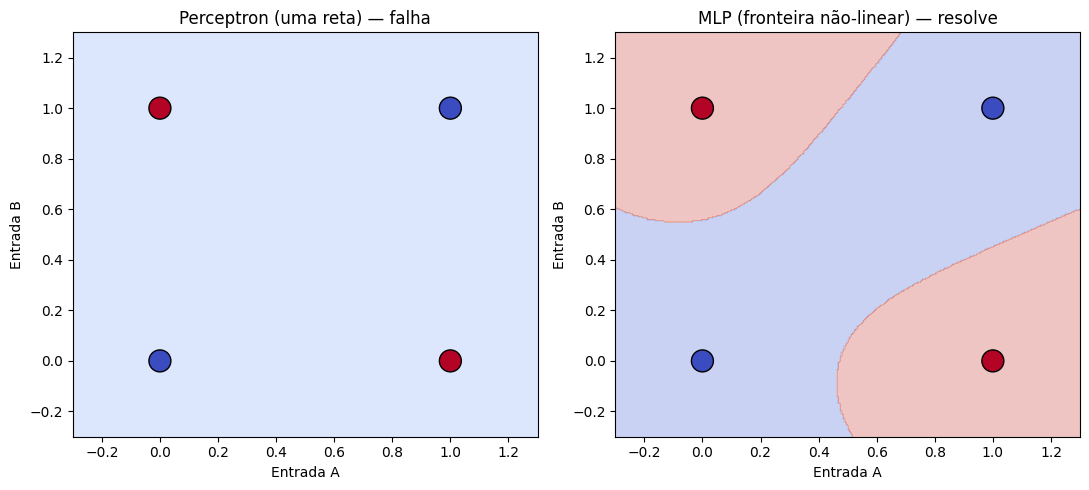

In [7]:
def plot_fronteira(modelo, X, y, titulo, ax):
    # cria uma grade de pontos e pinta a região de cada classe
    xx, yy = np.meshgrid(np.linspace(-0.3, 1.3, 300),
                         np.linspace(-0.3, 1.3, 300))
    Z = modelo.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    ax.scatter(X[:, 0], X[:, 1], c=y, s=250, edgecolor="k", cmap="coolwarm")
    ax.set_title(titulo)
    ax.set_xlabel("Entrada A"); ax.set_ylabel("Entrada B")

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
plot_fronteira(perceptron, X_xor, y_xor, "Perceptron (uma reta) — falha", axes[0])
plot_fronteira(mlp_xor,    X_xor, y_xor, "MLP (fronteira não-linear) — resolve", axes[1])
plt.tight_layout(); plt.show()

## 2. Pipeline completo com um dataset real: Iris

Agora vamos do "brinquedo" (XOR) para um problema real. Usaremos o **Iris**
(o mesmo da Aula 04): classificar flores em **3 espécies** a partir de **4 medidas**
(comprimento/largura da sépala e da pétala).

O pipeline é o **mesmo de qualquer modelo supervisionado**:
**carregar → explorar → separar treino/teste → normalizar → treinar → avaliar**.

In [8]:
iris = load_iris()
X = iris.data          # 150 amostras x 4 atributos
y = iris.target        # classe: 0=setosa, 1=versicolor, 2=virginica

# Montamos um DataFrame só para visualizar melhor
df = pd.DataFrame(X, columns=iris.feature_names)
df["especie"] = [iris.target_names[i] for i in y]
print("Formato dos dados:", X.shape)
print("Classes:", iris.target_names)
df.head()

Formato dos dados: (150, 4)
Classes: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),especie
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### 2.1 Separando treino e teste (Holdout)

`stratify=y` mantém a **mesma proporção de classes** nos dois conjuntos.

In [9]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y,
    test_size=0.30,      # 30% para teste
    random_state=42,     # resultado reproduzível
    stratify=y           # mantém proporção das 3 classes
)
print("Treino:", X_treino.shape[0], "amostras")
print("Teste :", X_teste.shape[0], "amostras")

Treino: 105 amostras
Teste : 45 amostras


### 2.2 Normalização (pré-processamento)

Como vimos na aula de **normalização**, atributos em escalas diferentes atrapalham o aprendizado. Em redes neurais isso é ainda mais sério, porque os **pesos** e o **gradiente** ficam desbalanceados e o treino fica lento ou instável.

Usamos o `StandardScaler` (média 0, desvio 1).

Ajustamos o scaler **só no treino** (`fit_transform`) e apenas **aplicamos** no teste (`transform`) — para não "vazar" informação do teste.

In [10]:
scaler = StandardScaler()
X_treino_norm = scaler.fit_transform(X_treino)   # aprende a escala NO TREINO
X_teste_norm  = scaler.transform(X_teste)        # apenas aplica no teste

print("Antes  (1ª amostra):", X_treino[0])
print("Depois (1ª amostra):", X_treino_norm[0].round(2))

Antes  (1ª amostra): [5.1 2.5 3.  1.1]
Depois (1ª amostra): [-0.9  -1.22 -0.44 -0.14]


## 3. Treinando o MLP

Cada hiperparâmetro abaixo corresponde a um conceito da teoria:

| Hiperparâmetro | O que é | Conexão com a teoria |
|---|---|---|
| `hidden_layer_sizes=(8, 8)` | nº de neurônios em cada **camada oculta** | aqui: 2 camadas de 8 neurônios |
| `activation="relu"` | **função de ativação** dos neurônios | introduz a **não-linearidade** |
| `solver="adam"` | algoritmo de otimização | versão moderna do **gradiente descendente** |
| `learning_rate_init=0.01` | **taxa de aprendizado** | tamanho do passo a cada ajuste de peso |
| `max_iter=1000` | nº máximo de **épocas** | quantas vezes percorre os dados no treino |

O `fit` executa o **backpropagation** que vocês viram na teoria: a rede faz uma
previsão, calcula o erro e ajusta os pesos camada por camada.

In [11]:
mlp = MLPClassifier(
    hidden_layer_sizes=(8, 8),   # 2 camadas ocultas, 8 neurônios cada
    activation="relu",
    solver="adam",
    learning_rate_init=0.01,
    max_iter=1000,
    random_state=42
)

mlp.fit(X_treino_norm, y_treino)   # <-- aqui acontece o treinamento (backpropagation)
print("Treinamento concluído!")
print("Convergiu em", mlp.n_iter_, "épocas")

Treinamento concluído!
Convergiu em 253 épocas


## 4. Avaliando o modelo

In [12]:
prev = mlp.predict(X_teste_norm)

acc_treino = mlp.score(X_treino_norm, y_treino)
acc_teste  = accuracy_score(y_teste, prev)
print(f"Acurácia no TREINO: {acc_treino:.1%}")
print(f"Acurácia no TESTE : {acc_teste:.1%}")

Acurácia no TREINO: 100.0%
Acurácia no TESTE : 91.1%


### 4.2 Relatório por classe

`precision`, `recall` e `f1-score` por espécie — métricas da Aula 09.

In [13]:
print(classification_report(y_teste, prev, target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.79      1.00      0.88        15
   virginica       1.00      0.73      0.85        15

    accuracy                           0.91        45
   macro avg       0.93      0.91      0.91        45
weighted avg       0.93      0.91      0.91        45



### 4.3 Matriz de confusão

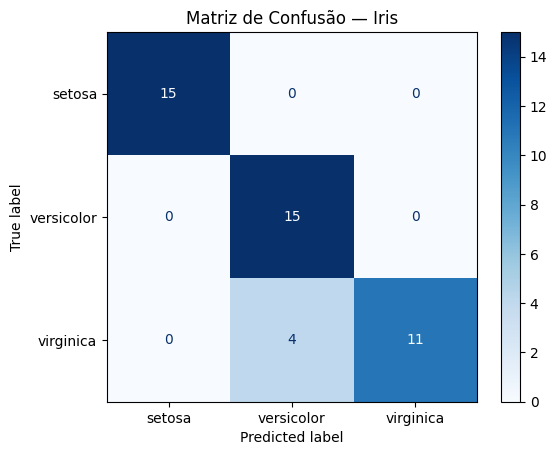

In [14]:
cm = confusion_matrix(y_teste, prev)
disp = ConfusionMatrixDisplay(cm, display_labels=iris.target_names)
disp.plot(cmap="Blues")
plt.title("Matriz de Confusão — Iris")
plt.show()

### 4.4 Curva de perda (*loss*)

A rede ajusta os pesos para **minimizar o erro (loss)** a cada época.
Uma curva que **desce e estabiliza** indica que o treino convergiu bem.

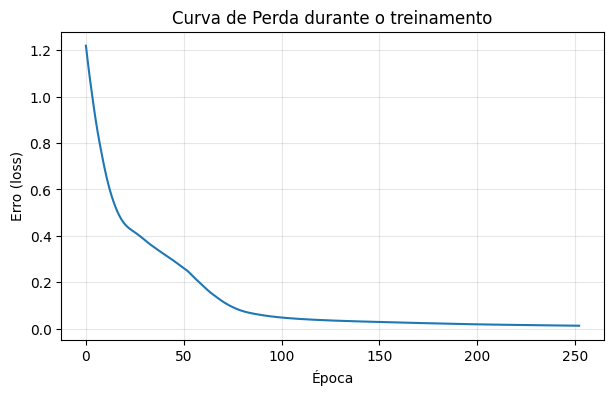

In [15]:
plt.figure(figsize=(7, 4))
plt.plot(mlp.loss_curve_)
plt.title("Curva de Perda durante o treinamento")
plt.xlabel("Época"); plt.ylabel("Erro (loss)")
plt.grid(alpha=0.3); plt.show()

## 5. Experimentando a arquitetura + validação cruzada

### 5.1 Mudando o número de neurônios/camadas

A **arquitetura** (quantos neurônios e camadas) muda o poder do modelo.

In [16]:
arquiteturas = [(2,), (8,), (8, 8), (50, 50)]

for arq in arquiteturas:
    m = MLPClassifier(hidden_layer_sizes=arq, max_iter=1000, random_state=42)
    m.fit(X_treino_norm, y_treino)
    tr = m.score(X_treino_norm, y_treino)
    te = m.score(X_teste_norm, y_teste)
    print(f"Camadas {str(arq):10s} -> treino: {tr:.1%} | teste: {te:.1%}")

/home/gladistony/Github/inteligencia-artificial-2026.1/.venv/lib64/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/gladistony/Github/inteligencia-artificial-2026.1/.venv/lib64/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Camadas (2,)       -> treino: 87.6% | teste: 80.0%
Camadas (8,)       -> treino: 98.1% | teste: 88.9%
Camadas (8, 8)     -> treino: 99.0% | teste: 93.3%
Camadas (50, 50)   -> treino: 100.0% | teste: 93.3%


### 5.2 Validação cruzada (k-fold)

In [17]:
# normalizamos todo o X para a validação cruzada
X_norm = StandardScaler().fit_transform(X)

modelo_cv = MLPClassifier(hidden_layer_sizes=(8, 8), max_iter=1000, random_state=42)
scores = cross_val_score(modelo_cv, X_norm, y, cv=5)   # 5-fold

print("Acurácia em cada fold:", np.round(scores, 3))
print(f"Média: {scores.mean():.1%}  (+/- {scores.std():.1%})")

Acurácia em cada fold: [0.967 0.967 0.933 0.933 1.   ]
Média: 96.0%  (+/- 2.5%)
